<a href="https://colab.research.google.com/github/vgayathri13/VRSU/blob/main/RealObjectDetection8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


image 1/1 /content/street.jpg: 448x640 1 bench, 2 potted plants, 405.2ms
Speed: 17.5ms preprocess, 405.2ms inference, 44.8ms postprocess per image at shape (1, 3, 448, 640)
bench: 0.73 at [0, 183, 39, 208]
potted plant: 0.70 at [522, 150, 539, 177]
potted plant: 0.64 at [83, 154, 114, 184]


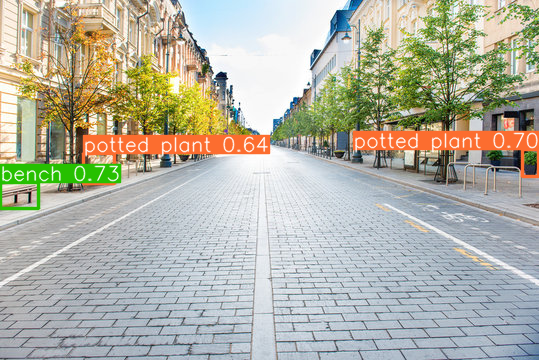

In [2]:
# Install library (run once in Colab)
!pip install ultralytics

# Import libraries
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load pretrained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Run detection on image
results = model('/content/street.jpg', conf=0.5)

# Process detection results
for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        print(f'{cls_name}: {conf:.2f} at [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]')

# Show image with bounding boxes
annotated = results[0].plot()
cv2_imshow(annotated)